In [1]:
#Importing the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import joblib
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler,MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.svm import SVR,SVC
from xgboost import XGBRegressor, XGBClassifier
import math
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score,confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
#Setting the working directory
setwd = "D:/Sathish/AIML/Real Estate Investment Advisor/"

In [4]:
#Importing the dataset
data = pd.read_csv("india_housing_prices.csv")

In [5]:
pd.set_option('display.max_columns',None)

In [6]:
display(data.head())
print('\nLast six observation')
display(data.tail())

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,Furnished,22,1,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,Unfurnished,21,20,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,Semi-furnished,19,27,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,Furnished,21,26,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,Semi-furnished,3,2,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move



Last six observation


,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
249995,249996,Gujarat,Ahmedabad,Locality_187,Independent House,5,1995,274.75,0.14,1995,Furnished,19,7,30,8,6,Low,No,No,"Playground, Garden, Gym, Clubhouse, Pool",East,Broker,Under_Construction
249996,249997,Tamil Nadu,Chennai,Locality_348,Apartment,1,2293,13.40,0.01,2013,Semi-furnished,15,25,12,8,10,Low,No,No,Playground,South,Broker,Ready_to_Move
249997,249998,Telangana,Warangal,Locality_225,Villa,4,2910,236.94,0.08,2003,Furnished,21,30,22,10,4,High,Yes,Yes,Playground,South,Builder,Under_Construction
249998,249999,Odisha,Cuttack,Locality_138,Villa,1,1149,141.66,0.12,2007,Unfurnished,14,11,18,3,7,Low,Yes,Yes,"Playground, Gym, Pool",South,Owner,Ready_to_Move
249999,250000,Haryana,Gurgaon,Locality_268,Independent House,3,4313,199.69,0.05,1990,Semi-furnished,22,28,35,10,6,Medium,No,No,"Gym, Garden",South,Owner,Under_Construction


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  object 
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  object 
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_in_Lakhs                  250000 non-null  float64
 8   Price_per_SqFt                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  object 
 11  Floor_No                        250000 non-null  int64  
 12  Total_Floors    

In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
data.dtypes

ID                                  int64
State                              object
City                               object
Locality                           object
Property_Type                      object
BHK                                 int64
Size_in_SqFt                        int64
Price_in_Lakhs                    float64
Price_per_SqFt                    float64
Year_Built                          int64
Furnished_Status                   object
Floor_No                            int64
Total_Floors                        int64
Age_of_Property                     int64
Nearby_Schools                      int64
Nearby_Hospitals                    int64
Public_Transport_Accessibility     object
Parking_Space                      object
Security                           object
Amenities                          object
Facing                             object
Owner_Type                         object
Availability_Status                object
dtype: object

In [10]:
#Data types needs to be converted
"""
ID has to be changed to str
Year_Built variable has to be changed to Datatimeindex
"""
data['Year_Built']=pd.DatetimeIndex(data['Year_Built'])
data['ID'] = data['ID'].astype(str)

In [11]:
data.dtypes

ID                                        object
State                                     object
City                                      object
Locality                                  object
Property_Type                             object
BHK                                        int64
Size_in_SqFt                               int64
Price_in_Lakhs                           float64
Price_per_SqFt                           float64
Year_Built                        datetime64[ns]
Furnished_Status                          object
Floor_No                                   int64
Total_Floors                               int64
Age_of_Property                            int64
Nearby_Schools                             int64
Nearby_Hospitals                           int64
Public_Transport_Accessibility            object
Parking_Space                             object
Security                                  object
Amenities                                 object
Facing              

In [12]:
#Define a function to check the outliers
def check_outlier(x,y):
    q1 = x.quantile(0.25)
    q2 = x.quantile(0.50)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    uf = q3 + 1.5*iqr
    lf = q1 - 1.5*iqr
    upper = (x >= uf).sum()
    below = (x <= lf).sum()
    return f'({y}: {below, upper})'
#Are there any outliers in price per sq ft or property size?
#Checking the outliers in the numeric variables in the dataset
for i in data.select_dtypes(include="number").columns:
    print(check_outlier(data[i],i))

(BHK: (np.int64(0), np.int64(0)))
(Size_in_SqFt: (np.int64(0), np.int64(0)))
(Price_in_Lakhs: (np.int64(0), np.int64(0)))
(Price_per_SqFt: (np.int64(0), np.int64(20020)))
(Floor_No: (np.int64(0), np.int64(0)))
(Total_Floors: (np.int64(0), np.int64(0)))
(Age_of_Property: (np.int64(0), np.int64(0)))
(Nearby_Schools: (np.int64(0), np.int64(0)))
(Nearby_Hospitals: (np.int64(0), np.int64(0)))


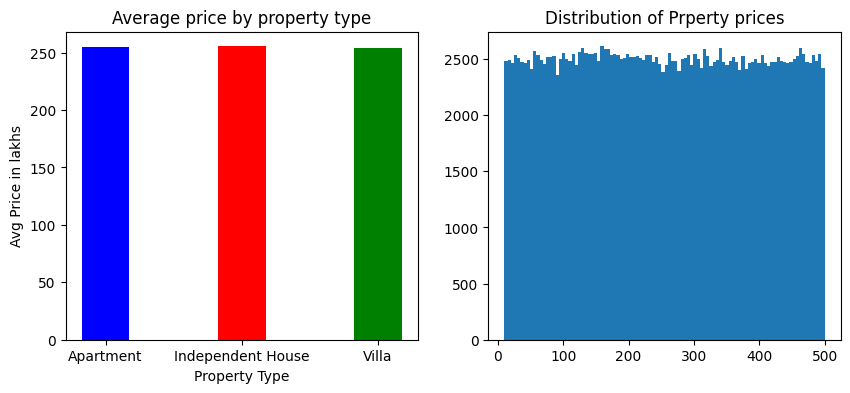

In [ ]:
#Exploratory Data Analysis
#Q1: Distribution of Property prices
fig,ax = plt.subplots(1,2,figsize=(10,4))
a=data.groupby('Property_Type')['Price_in_Lakhs'].mean().reset_index()
ax[0].bar(a['Property_Type'],a['Price_in_Lakhs'],color=['blue','red','green'],width=0.35)
ax[0].set_xlabel("Property Type")
ax[0].set_ylabel("Avg Price in lakhs")
ax[0].set_title("Average price by property type")

ax[1].hist(data['Price_in_Lakhs'],bins=100)
ax[1].set_title("Distribution of Property prices")
plt.show()

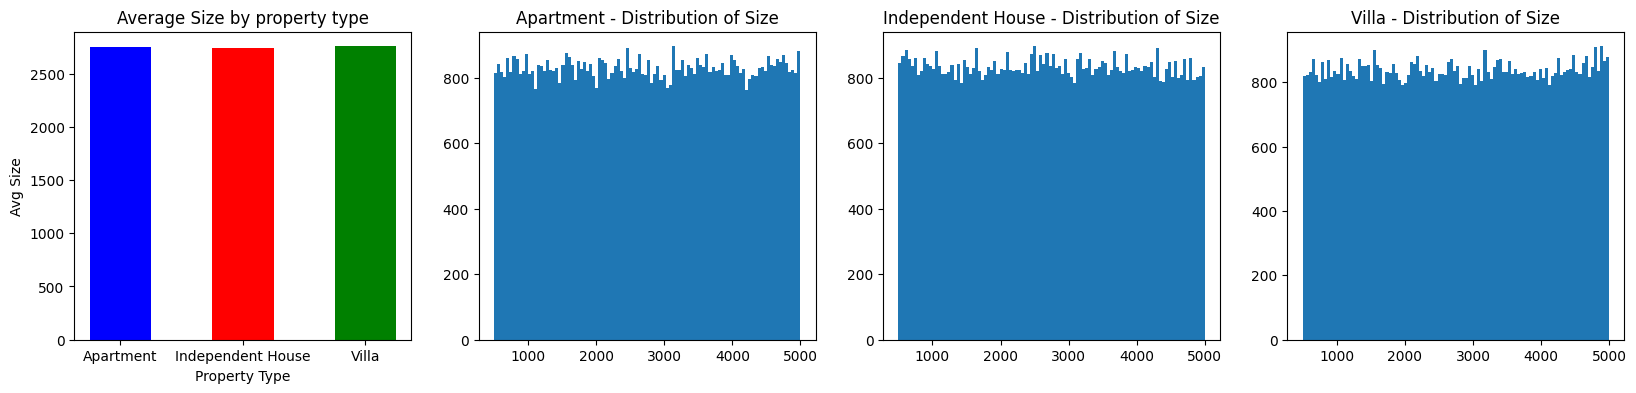

In [14]:
#Q2: Distribution of Property Sizes
fig,ax = plt.subplots(1,4,figsize=(20,4))
b = data.groupby('Property_Type')['Size_in_SqFt'].mean().reset_index()
ax[0].bar(b['Property_Type'],b['Size_in_SqFt'],color=['blue','red','green'],width=0.5)
ax[0].set_xlabel("Property Type")
ax[0].set_ylabel("Avg Size")
ax[0].set_title("Average Size by property type")

ax[1].hist(data[data['Property_Type']=='Apartment']['Size_in_SqFt'],bins = 100)
ax[1].set_title("Apartment - Distribution of Size")

ax[2].hist(data[data['Property_Type']=='Independent House']['Size_in_SqFt'],bins = 100)
ax[2].set_title("Independent House - Distribution of Size")

ax[3].hist(data[data['Property_Type']=='Villa']['Size_in_SqFt'],bins = 100)
ax[3].set_title("Villa - Distribution of Size")
plt.show()

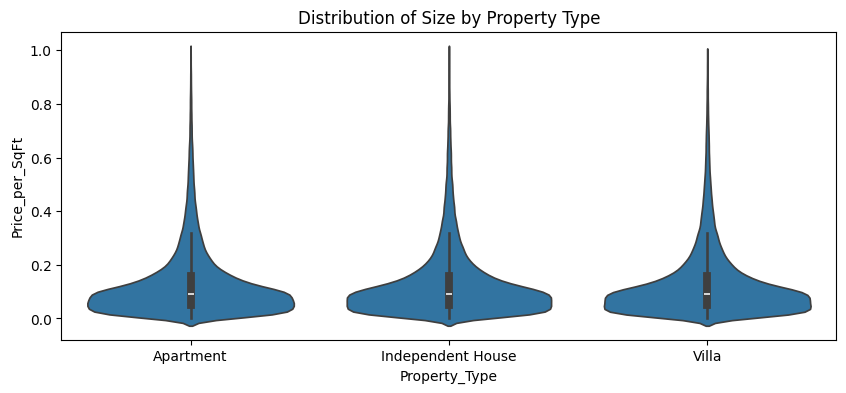

In [15]:
#Q3: Distribution of Price_persqft by property type
plt.figure(figsize=(10,4))
sns.violinplot(x=data['Property_Type'],y=data['Price_per_SqFt'],inner="box")
plt.title("Distribution of Size by Property Type")
plt.show()

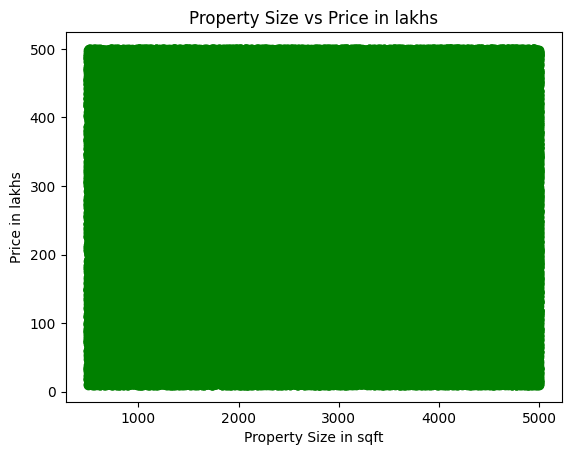

In [16]:
#Q4: Relationship between Property size and price
plt.scatter(data['Size_in_SqFt'],data['Price_in_Lakhs'],marker = 'o',color = 'green',label='current price per sqft')
plt.title("Property Size vs Price in lakhs")
plt.ylabel("Price in lakhs")
plt.xlabel("Property Size in sqft")
plt.show()

In [17]:
#To examine the relationship between the Size and Price
data.groupby('Size_in_SqFt')['Price_in_Lakhs'].describe()

,count,mean,std,min,25%,50%,75%,max
Size_in_SqFt,,,,,,,,
500,57.0,260.345088,142.779498,11.67,141.1800,268.150,377.1900,495.91
501,55.0,284.189091,136.686171,10.50,181.0500,280.210,408.8550,493.09
502,50.0,248.069200,151.889342,18.95,100.0425,241.645,377.1750,490.06
503,68.0,277.554853,150.400235,16.48,144.7525,310.580,409.7525,498.12
504,64.0,252.304844,134.239701,13.04,142.7925,245.475,345.8475,499.40
...,...,...,...,...,...,...,...,...
4996,50.0,256.925800,161.353026,15.87,117.6025,247.525,417.7350,494.93
4997,66.0,280.180000,136.841084,14.43,169.4275,288.000,393.7600,496.56
4998,68.0,282.132353,137.840365,33.23,165.0675,287.965,393.8600,497.96


In [18]:
#Q5: Are there any outliers in price per sqft or property Size
print(check_outlier(data['Price_per_SqFt'],"Price_per_SqFt"))
print(check_outlier(data['Size_in_SqFt'],"Size_in_SqFt"))
print(check_outlier(data['Price_in_Lakhs'],'Price_in_Lakhs'))
#As the Size and Price doesn't has a outlier but the price per sqft has

(Price_per_SqFt: (np.int64(0), np.int64(20020)))
(Size_in_SqFt: (np.int64(0), np.int64(0)))
(Price_in_Lakhs: (np.int64(0), np.int64(0)))


In [19]:
#Manually creating a Price per sqft variable and check whether it has outlier
data['Price_p_s'] = (data['Price_in_Lakhs']*100000)/data['Size_in_SqFt']
check_outlier(data['Price_p_s'],'Price_per_sqft')

'(Price_per_sqft: (np.int64(0), np.int64(19723)))'

In [20]:
data[['Price_in_Lakhs','Size_in_SqFt','Price_per_SqFt','Price_p_s']].head(8)

,Price_in_Lakhs,Size_in_SqFt,Price_per_SqFt,Price_p_s
0,489.76,4740,0.10,10332.489451
1,195.52,2364,0.08,8270.727580
2,183.79,3642,0.05,5046.403075
3,300.29,2741,0.11,10955.490697
4,182.90,4823,0.04,3792.245490
5,135.28,3500,0.04,3865.142857
6,318.12,4826,0.07,6591.794447
7,141.39,4252,0.03,3325.258702


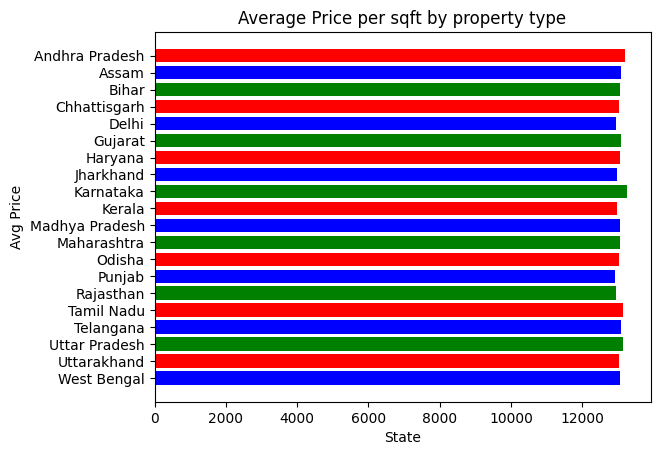

In [ ]:
# Location based analysis
#Q6: Average price per sqft by State
c = data.groupby('State')['Price_p_s'].mean().reset_index()
c = c.sort_values('State',ascending=False)
plt.barh(c['State'],c['Price_p_s'],color=['blue','red','green'])
plt.xlabel("Avg Price")
plt.ylabel("State")
plt.title("Average Price per sqft vs State")
plt.show()

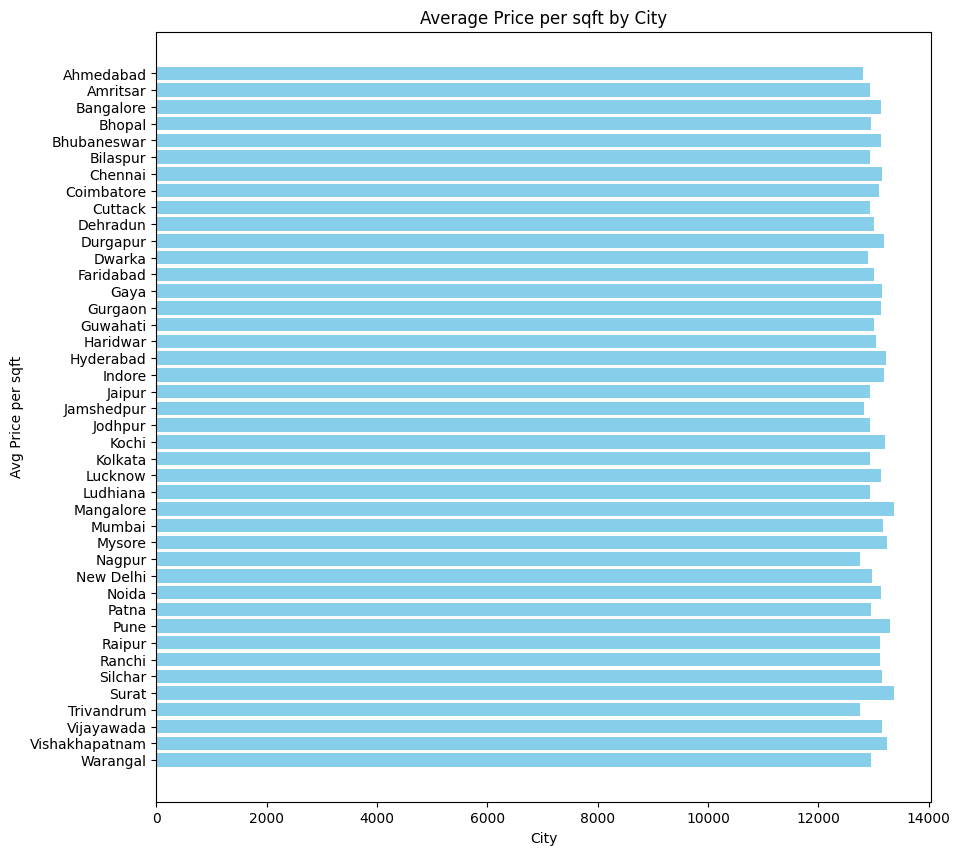

In [ ]:
#Q7: Average price per sqft by City
fig=plt.figure(figsize=(10,10))
d = data.groupby('City')['Price_p_s'].mean().reset_index()
d = d.sort_values('City',ascending=False)
plt.barh(d['City'],d['Price_p_s'],color='skyblue')
plt.xlabel("Avg Price")
plt.ylabel("City")
plt.title("Average Price per sqft by City")
plt.show()

In [23]:
#Q8: What is the median age of properties by locality
e=data.groupby('Locality')['Age_of_Property'].median().reset_index()
e.sort_values(by='Age_of_Property',ascending=False)

,Locality,Age_of_Property
470,Locality_72,21.0
338,Locality_403,21.0
473,Locality_75,20.0
31,Locality_127,20.0
0,Locality_1,20.0
...,...,...
452,Locality_56,17.0
34,Locality_13,17.0
460,Locality_63,17.0
1,Locality_10,17.0


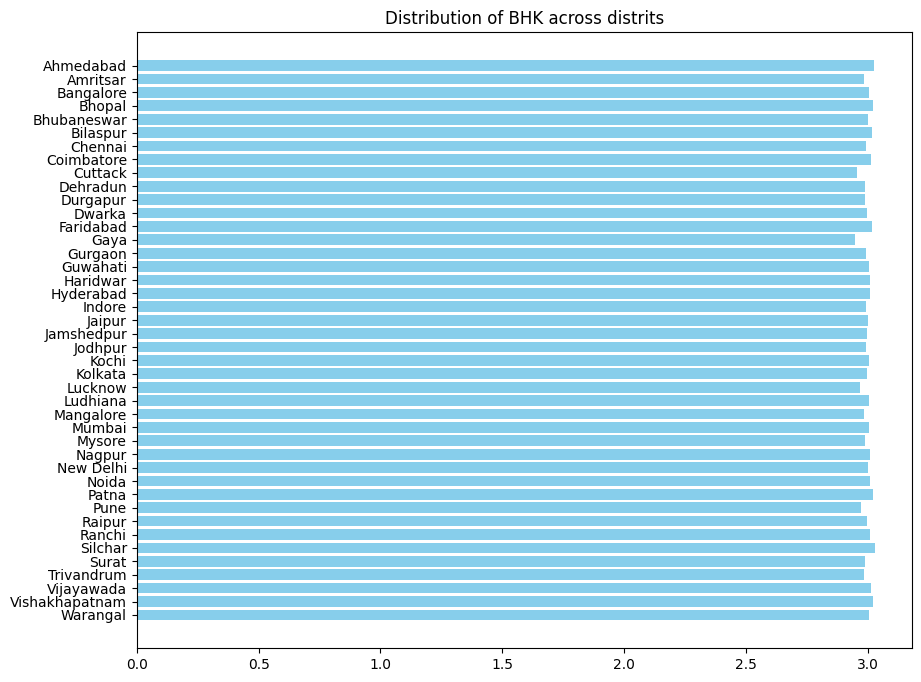

In [24]:
#Q8: How BHK distributed across cities
f = data.groupby('City')['BHK'].mean().reset_index()
f = f.sort_values(by='City',ascending=False)
fig=plt.figure(figsize=(10,8))
plt.barh(f['City'],f['BHK'],color='skyblue')
plt.title("Distribution of BHK across distrits")
plt.show()

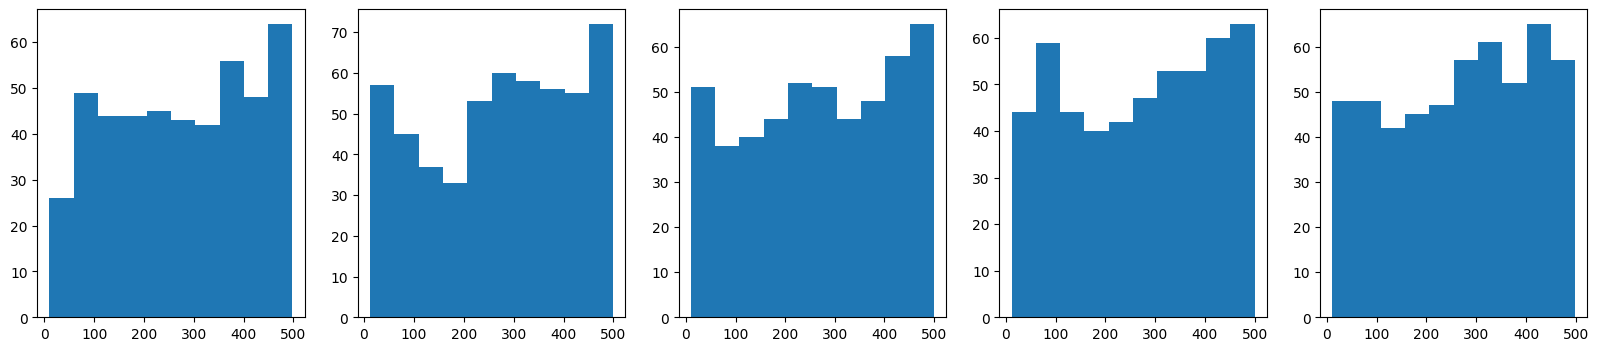

In [25]:
#Q10 What are the price trends for top 5 most expensive localities
g = data.groupby('Locality')['Price_in_Lakhs'].mean().reset_index()
g = g.sort_values(by='Price_in_Lakhs',ascending=False)
fig,ax=plt.subplots(1,5,figsize=(20,4))
ax[0].hist(data[data['Locality']=='Locality_395']['Price_in_Lakhs'],bins=10)
ax[1].hist(data[data['Locality']=='Locality_366']['Price_in_Lakhs'],bins=10)
ax[2].hist(data[data['Locality']=='Locality_497']['Price_in_Lakhs'],bins=10)
ax[3].hist(data[data['Locality']=='Locality_360']['Price_in_Lakhs'],bins=10)
ax[4].hist(data[data['Locality']=='Locality_203']['Price_in_Lakhs'],bins=10)
plt.show()

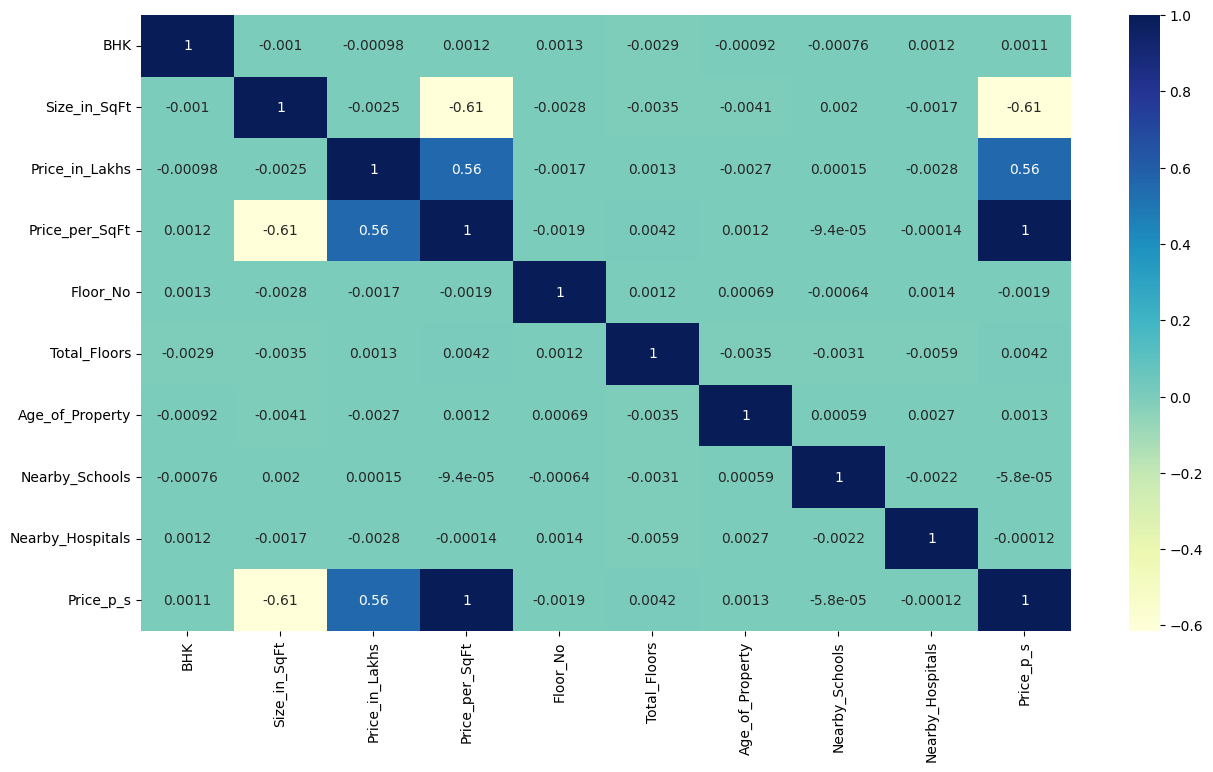

In [26]:
#Q11: How numeric features correlated with each other
numeric = data.select_dtypes(include='number')
numeric_corr = numeric.corr()
fig=plt.figure(figsize=(15,8))
sns.heatmap(numeric_corr,annot=True,cmap="YlGnBu")
plt.show()
#Conclusion: drop either Size_in_SqFt or Price_per_SqFt in the independent variable as their correlation is -0.61

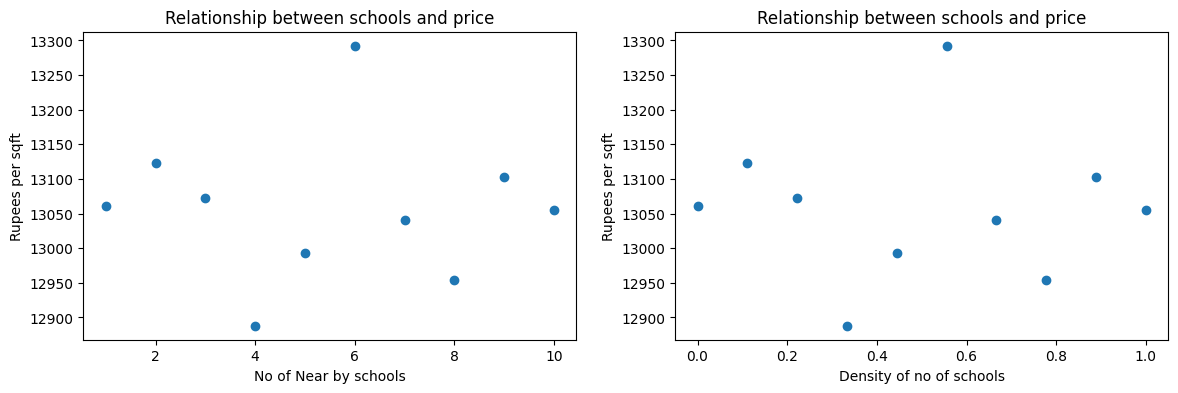

In [27]:
#Q12: How do nearby schools relate to price per sqft
f = data.groupby('Nearby_Schools')['Price_p_s'].mean().reset_index()
f = f.sort_values(by='Price_p_s',ascending=True)
fig,ax = plt.subplots(1,2,figsize=(14,4))
ax[0].scatter(f['Nearby_Schools'],f['Price_p_s'])
ax[0].set_xlabel("No of Near by schools")
ax[0].set_ylabel("Rupees per sqft")
ax[0].set_title("Relationship between schools and price")
#Creating a School density score
data[['School_density','Hospital_density']] = MinMaxScaler().fit_transform(data[['Nearby_Schools','Nearby_Hospitals']])
i = data.groupby('School_density')['Price_p_s'].mean().reset_index()
i = i.sort_values(by='Price_p_s',ascending=True)
ax[1].scatter(i['School_density'],i['Price_p_s'])
ax[1].set_xlabel("Density of no of schools")
ax[1].set_ylabel('Rupees per sqft')
ax[1].set_title("Relationship between schools and price")
plt.show()

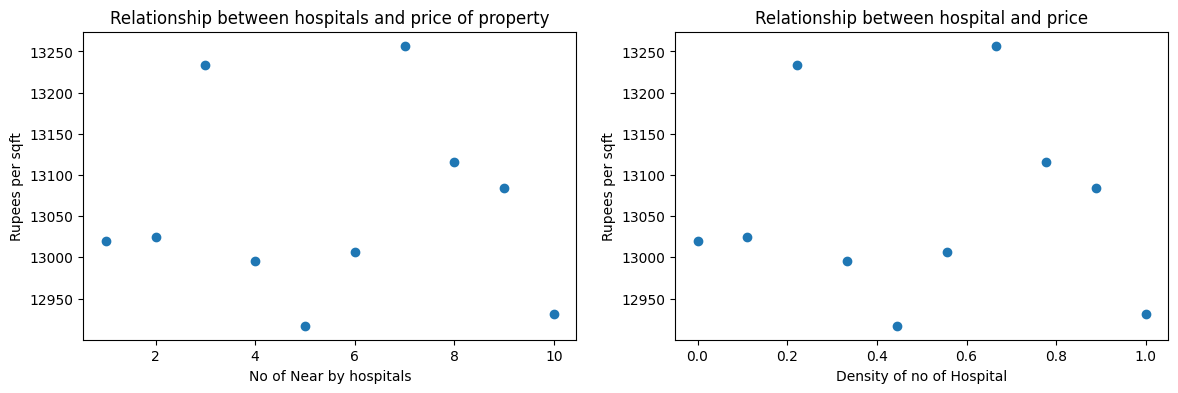

In [28]:
#Q13: How do nearyby hospital relate to price per sqft
fig,ax = plt.subplots(1,2,figsize=(14,4))
h = data.groupby('Nearby_Hospitals')['Price_p_s'].mean().reset_index()
h = h.sort_values(by='Price_p_s',ascending=True)
ax[0].scatter(h['Nearby_Hospitals'],h['Price_p_s'])
ax[0].set_xlabel("No of Near by hospitals")
ax[0].set_ylabel("Rupees per sqft")
ax[0].set_title("Relationship between hospitals and price of property")
i1 = data.groupby('Hospital_density')['Price_p_s'].mean().reset_index()
i1 = i1.sort_values(by='Price_p_s',ascending=True)
ax[1].scatter(i1['Hospital_density'],i1['Price_p_s'])
ax[1].set_xlabel("Density of no of Hospital")
ax[1].set_ylabel('Rupees per sqft')
ax[1].set_title("Relationship between hospital and price")
plt.show()

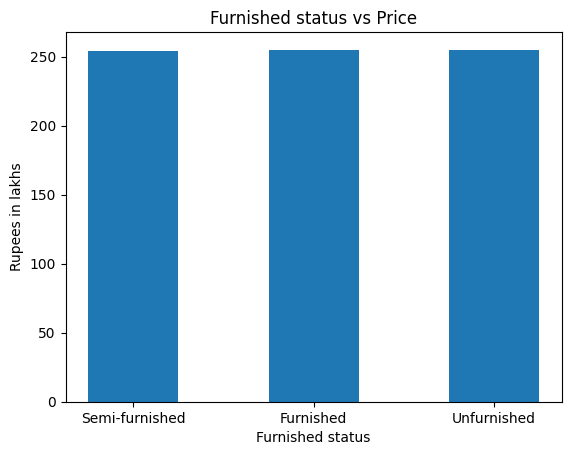

In [29]:
#Q14: How price vary by furnished status?
j = data.groupby('Furnished_Status')['Price_in_Lakhs'].mean().reset_index()
j = j.sort_values(by='Price_in_Lakhs',ascending=True)
plt.bar(j['Furnished_Status'],j['Price_in_Lakhs'],width=0.5)
plt.xlabel("Furnished status")
plt.ylabel("Rupees in lakhs")
plt.title("Furnished status vs Price")
plt.show()

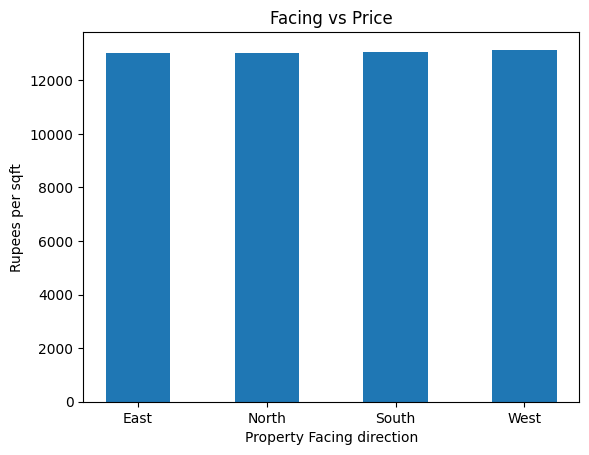

In [30]:
#Q15: How does price per sq ft vary by property facing direction?
k = data.groupby('Facing')['Price_p_s'].mean().reset_index()
k = k.sort_values(by='Price_p_s',ascending=True)
plt.bar(k['Facing'],k['Price_p_s'],width=0.5)
plt.xlabel("Property Facing direction")
plt.ylabel("Rupees per sqft")
plt.title("Facing vs Price")
plt.show()

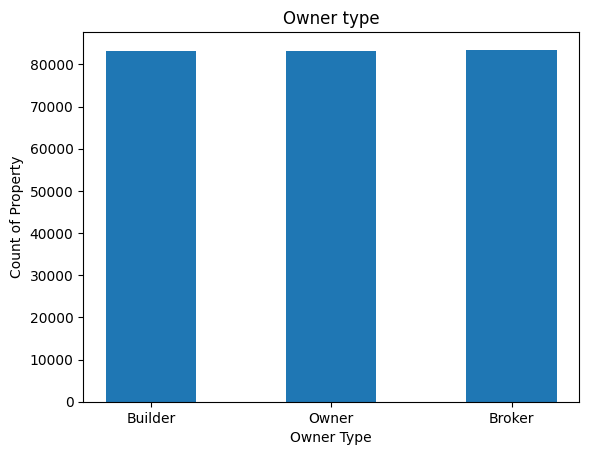

In [31]:
#Q16: How many properties belong to each owner type
l = data.groupby('Owner_Type')['ID'].count().reset_index()
l = l.sort_values(by='ID',ascending=True)
plt.bar(l['Owner_Type'],l['ID'],width=0.5)
plt.xlabel("Owner Type")
plt.ylabel("Count of Property")
plt.title("Owner type")
plt.show()

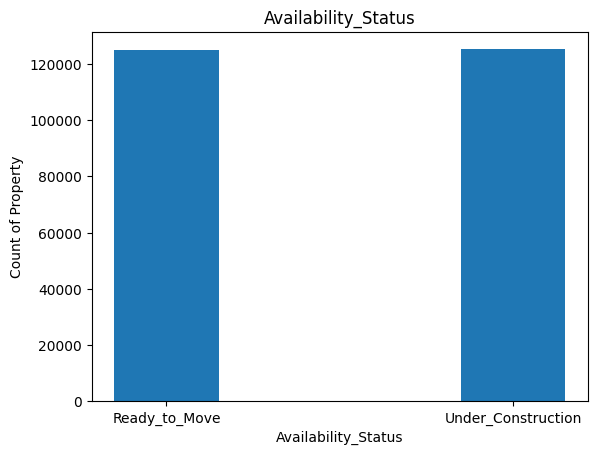

In [32]:
#Q17: How many properties are available under each availability status
m = data.groupby('Availability_Status')['ID'].count().reset_index()
m = m.sort_values(by='ID',ascending=True)
plt.bar(m['Availability_Status'],m['ID'],width=0.3)
plt.xlabel("Availability_Status")
plt.ylabel("Count of Property")
plt.title("Availability_Status")
plt.show()

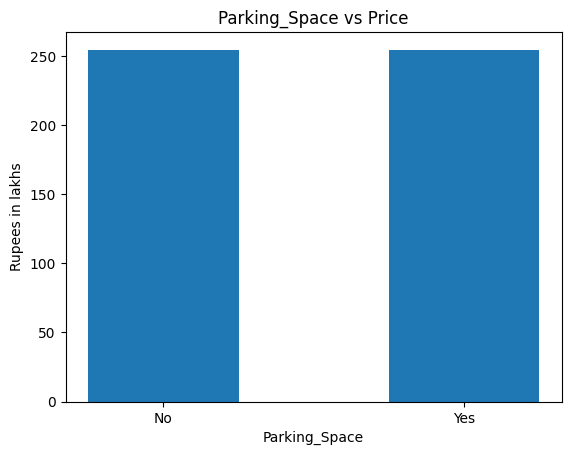

In [33]:
#Q18: Does parking space affect property price?
n = data.groupby('Parking_Space')['Price_in_Lakhs'].mean().reset_index()
n = n.sort_values(by='Price_in_Lakhs',ascending=True)
plt.bar(n['Parking_Space'],n['Price_in_Lakhs'],width=0.5)
plt.xlabel("Parking_Space")
plt.ylabel("Rupees in lakhs")
plt.title("Parking_Space vs Price")
plt.show()

In [34]:
#Creation of a dummy variable for each amenity facility
data['Amenities'] = data['Amenities'].apply(lambda x: [i.strip() for i in x.split(',')])
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
amenities = mlb.fit_transform(data['Amenities'])
amen = pd.DataFrame(amenities,columns=mlb.classes_)
data_1 = pd.concat([data,amen],axis=1)

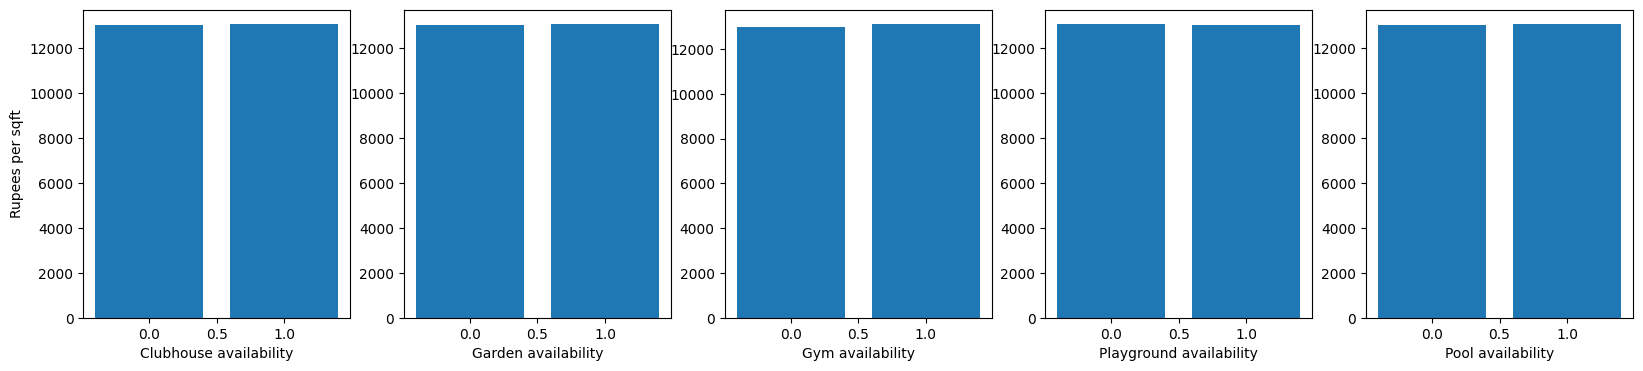

In [35]:
#Q19: How do amenities affect price per sqft?
clubh = data_1.groupby('Clubhouse')['Price_p_s'].mean().reset_index()
gard =  data_1.groupby('Garden')['Price_p_s'].mean().reset_index()
gym =  data_1.groupby('Gym')['Price_p_s'].mean().reset_index()
ply = data_1.groupby('Playground')['Price_p_s'].mean().reset_index()
pool = data_1.groupby('Pool')['Price_p_s'].mean().reset_index()
fig,ax = plt.subplots(1,5,figsize=(20,4))
ax[0].bar(clubh['Clubhouse'],clubh['Price_p_s'])
ax[0].set_xlabel("Clubhouse availability")
ax[0].set_ylabel("Rupees per sqft")
ax[1].bar(gard['Garden'],gard['Price_p_s'])
ax[1].set_xlabel("Garden availability")
ax[2].bar(gym['Gym'],gym['Price_p_s'])
ax[2].set_xlabel("Gym availability")
ax[3].bar(ply['Playground'],ply['Price_p_s'])
ax[3].set_xlabel("Playground availability")
ax[4].bar(pool['Pool'],pool['Price_p_s'])
ax[4].set_xlabel("Pool availability")
plt.show()

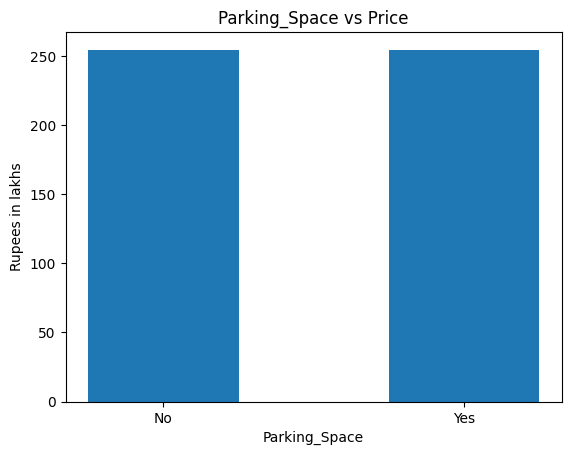

In [36]:
#Q20: How does public transport accessibility relate to price_per_sqft
p = data.groupby('Public_Transport_Accessibility')['Price_p_s'].mean().reset_index()
p = p.sort_values(by='Price_p_s',ascending=True)
plt.bar(n['Parking_Space'],n['Price_in_Lakhs'],width=0.5)
plt.xlabel("Parking_Space")
plt.ylabel("Rupees in lakhs")
plt.title("Parking_Space vs Price")
plt.show()

In [37]:
#Creation of a future price (growth) variable
#Creation of a growth rate using MCA algorithm
import prince
mca = prince.MCA(n_components=1)
a= MinMaxScaler(feature_range=(-15,25))
data_1['Growth_rate'] = a.fit_transform(mca.fit_transform(data_1[['City','Property_Type','Age_of_Property']]))
data_1['y_price'] = (data_1['Price_in_Lakhs'])*((1+(data_1['Growth_rate']*0.01)))**5

In [38]:
#data_1.drop(['Growth_rate','y_price'],axis=1,inplace=True)

In [39]:
data_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   ID                              250000 non-null  object        
 1   State                           250000 non-null  object        
 2   City                            250000 non-null  object        
 3   Locality                        250000 non-null  object        
 4   Property_Type                   250000 non-null  object        
 5   BHK                             250000 non-null  int64         
 6   Size_in_SqFt                    250000 non-null  int64         
 7   Price_in_Lakhs                  250000 non-null  float64       
 8   Price_per_SqFt                  250000 non-null  float64       
 9   Year_Built                      250000 non-null  datetime64[ns]
 10  Furnished_Status                250000 non-null  object 

In [40]:
data_1['Growth_rate'].quantile([0.00,0.01,0.10,0.25,0.35,0.50,0.51,0.75,0.99])

0.00   -15.000000
0.01   -11.676995
0.10    -4.852180
0.25    -0.320325
0.35     1.554693
0.50     4.399207
0.51     4.570029
0.75     9.536412
0.99    19.919442
Name: Growth_rate, dtype: float64

In [41]:
display(data_1['Price_in_Lakhs'].quantile([0.25,0.50,0.75,0.99]))
display(data_1['y_price'].quantile([0.25,0.50,0.75,0.99]))

0.25    132.5500
0.50    253.8700
0.75    376.8800
0.99    494.9201
Name: Price_in_Lakhs, dtype: float64

0.25    153.179997
0.50    294.950447
0.75    466.908366
0.99    959.250460
Name: y_price, dtype: float64

In [42]:
#Creation of Binary variable for investment
#It is created if the current price is lower than the median of that and higher than the future median
c = data_1['Price_in_Lakhs'].median()
f = data_1['y_price'].median()
display(c)
display(f)
data_1['y_class']=np.where((data_1['Price_in_Lakhs']<=c)&(data_1['Growth_rate']>=0),1,0)

np.float64(253.87)

np.float64(294.9504471127599)

In [43]:
data_1['y_class'].value_counts()

y_class
0    158098
1     91902
Name: count, dtype: int64

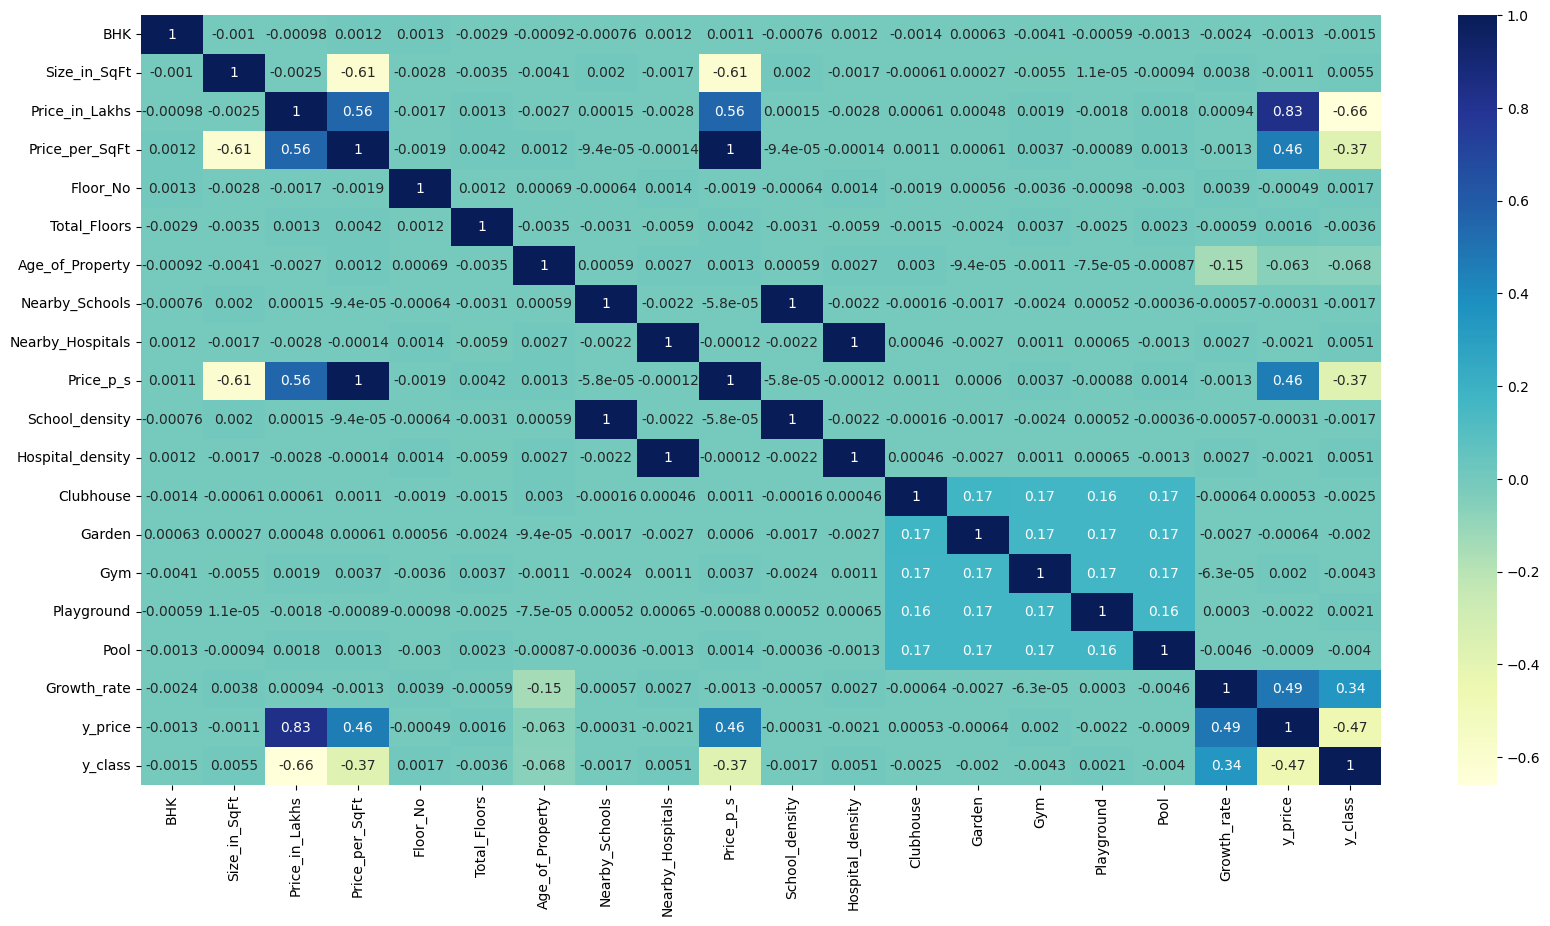

In [44]:
#Checking Multicollinearity
numeric_1 = data_1.select_dtypes(include='number')
num_corr = numeric_1.corr()
fig=plt.figure(figsize=(20,10))
sns.heatmap(num_corr,annot=True,cmap="YlGnBu")
plt.show()

In [45]:
#Preprocessing the dataset for the model
""" 
As it is noted from the EDA that the Size_in_SqFt correlated (-0.61) with Price_per_SqFt
Drop the variables in X: ID, Amenities, Year_Built, Price_per_SqFt (also Price_p_s), Growth rate (0.55 corr with y_price)
Minmaxscaling to be done for the Nearby_Schools and Nearby_Hospitals after splitting the dataset so the School_density and Hospital_density are dropped
Standardisation to be done for the numeric variables and also dependent (y_price) also standardised to make uniformity in all scales.
"""

' \nAs it is noted from the EDA that the Size_in_SqFt correlated (-0.61) with Price_per_SqFt\nDrop the variables in X: ID, Amenities, Year_Built, Price_per_SqFt (also Price_p_s), Growth rate (0.55 corr with y_price)\nMinmaxscaling to be done for the Nearby_Schools and Nearby_Hospitals after splitting the dataset so the School_density and Hospital_density are dropped\nStandardisation to be done for the numeric variables and also dependent (y_price) also standardised to make uniformity in all scales.\n'

In [46]:
data_1.drop(['School_density','Hospital_density'],axis=1,inplace=True)

In [ ]:
#Exporting the dataset to csv format
data_1.to_csv("Data.csv",index=False)

In [47]:
X = data_1.drop(['ID','Price_per_SqFt','Price_p_s','Year_Built','Amenities','Growth_rate','y_price','y_class'],axis = 1)

In [48]:
X.head()

,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Furnished_Status,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Facing,Owner_Type,Availability_Status,Clubhouse,Garden,Gym,Playground,Pool
0,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,Furnished,22,1,35,10,3,High,No,No,West,Owner,Ready_to_Move,1,1,1,1,1
1,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,Unfurnished,21,20,17,8,1,Low,No,Yes,North,Builder,Under_Construction,1,1,1,1,1
2,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,Semi-furnished,19,27,28,9,8,Low,Yes,No,South,Broker,Ready_to_Move,1,0,1,1,1
3,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,Furnished,21,26,34,5,7,High,Yes,Yes,North,Builder,Ready_to_Move,1,1,1,1,1
4,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,Semi-furnished,3,2,23,4,9,Low,No,Yes,East,Builder,Ready_to_Move,1,1,1,1,1


In [49]:
#Binary Map {1,0} to the binary categorical variables
X['Parking_Space'] = X['Parking_Space'].map({'No':0, 'Yes':1})
X['Security'] = X['Security'].map({'No':0, 'Yes':1})
X['Availability_Status'] = X['Availability_Status'].map({'Under_Construction':0, 'Ready_to_Move':1})


In [50]:
X.head()

,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Furnished_Status,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Facing,Owner_Type,Availability_Status,Clubhouse,Garden,Gym,Playground,Pool
0,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,Furnished,22,1,35,10,3,High,0,0,West,Owner,1,1,1,1,1,1
1,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,Unfurnished,21,20,17,8,1,Low,0,1,North,Builder,0,1,1,1,1,1
2,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,Semi-furnished,19,27,28,9,8,Low,1,0,South,Broker,1,1,0,1,1,1
3,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,Furnished,21,26,34,5,7,High,1,1,North,Builder,1,1,1,1,1,1
4,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,Semi-furnished,3,2,23,4,9,Low,0,1,East,Builder,1,1,1,1,1,1


In [51]:
X = pd.get_dummies(X,columns=['State','City','Locality','Property_Type','Furnished_Status','Public_Transport_Accessibility','Facing','Owner_Type'])

In [52]:
#Dropping the baseline category of the dummy variable inotherwords we can say that setting the baseline for that dummy variable
X.drop(X[['State_Andhra Pradesh','City_Ahmedabad','Locality_Locality_1','Property_Type_Apartment','Furnished_Status_Unfurnished','Public_Transport_Accessibility_Low','Facing_North','Owner_Type_Broker']],axis=1,inplace=True)

In [53]:
X.head()

,BHK,Size_in_SqFt,Price_in_Lakhs,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Parking_Space,Security,Availability_Status,Clubhouse,Garden,Gym,Playground,Pool,State_Assam,State_Bihar,State_Chhattisgarh,State_Delhi,State_Gujarat,State_Haryana,State_Jharkhand,State_Karnataka,State_Kerala,State_Madhya Pradesh,State_Maharashtra,State_Odisha,State_Punjab,State_Rajasthan,State_Tamil Nadu,State_Telangana,State_Uttar Pradesh,State_Uttarakhand,State_West Bengal,City_Amritsar,City_Bangalore,City_Bhopal,City_Bhubaneswar,City_Bilaspur,City_Chennai,City_Coimbatore,City_Cuttack,City_Dehradun,City_Durgapur,City_Dwarka,City_Faridabad,City_Gaya,City_Gurgaon,City_Guwahati,City_Haridwar,City_Hyderabad,City_Indore,City_Jaipur,City_Jamshedpur,City_Jodhpur,City_Kochi,City_Kolkata,City_Lucknow,City_Ludhiana,City_Mangalore,City_Mumbai,City_Mysore,City_Nagpur,City_New Delhi,City_Noida,City_Patna,City_Pune,City_Raipur,City_Ranchi,City_Silchar,City_Surat,City_Trivandrum,City_Vijayawada,City_Vishakhapatnam,City_Warangal,Locality_Locality_10,Locality_Locality_100,Locality_Locality_101,Locality_Locality_102,Locality_Locality_103,Locality_Locality_104,Locality_Locality_105,Locality_Locality_106,Locality_Locality_107,Locality_Locality_108,Locality_Locality_109,Locality_Locality_11,Locality_Locality_110,Locality_Locality_111,Locality_Locality_112,Locality_Locality_113,Locality_Locality_114,Locality_Locality_115,Locality_Locality_116,Locality_Locality_117,Locality_Locality_118,Locality_Locality_119,Locality_Locality_12,Locality_Locality_120,Locality_Locality_121,Locality_Locality_122,Locality_Locality_123,Locality_Locality_124,Locality_Locality_125,Locality_Locality_126,Locality_Locality_127,Locality_Locality_128,Locality_Locality_129,Locality_Locality_13,Locality_Locality_130,Locality_Locality_131,Locality_Locality_132,Locality_Locality_133,Locality_Locality_134,Locality_Locality_135,Locality_Locality_136,Locality_Locality_137,Locality_Locality_138,Locality_Locality_139,Locality_Locality_14,Locality_Locality_140,Locality_Locality_141,Locality_Locality_142,Locality_Locality_143,Locality_Locality_144,Locality_Locality_145,Locality_Locality_146,Locality_Locality_147,Locality_Locality_148,Locality_Locality_149,Locality_Locality_15,Locality_Locality_150,Locality_Locality_151,Locality_Locality_152,Locality_Locality_153,Locality_Locality_154,Locality_Locality_155,Locality_Locality_156,Locality_Locality_157,Locality_Locality_158,Locality_Locality_159,Locality_Locality_16,Locality_Locality_160,Locality_Locality_161,Locality_Locality_162,Locality_Locality_163,Locality_Locality_164,Locality_Locality_165,Locality_Locality_166,Locality_Locality_167,Locality_Locality_168,Locality_Locality_169,Locality_Locality_17,Locality_Locality_170,Locality_Locality_171,Locality_Locality_172,Locality_Locality_173,Locality_Locality_174,Locality_Locality_175,Locality_Locality_176,Locality_Locality_177,Locality_Locality_178,Locality_Locality_179,Locality_Locality_18,Locality_Locality_180,Locality_Locality_181,Locality_Locality_182,Locality_Locality_183,Locality_Locality_184,Locality_Locality_185,Locality_Locality_186,Locality_Locality_187,Locality_Locality_188,Locality_Locality_189,Locality_Locality_19,Locality_Locality_190,Locality_Locality_191,Locality_Locality_192,Locality_Locality_193,Locality_Locality_194,Locality_Locality_195,Locality_Locality_196,Locality_Locality_197,Locality_Locality_198,Locality_Locality_199,Locality_Locality_2,Locality_Locality_20,Locality_Locality_200,Locality_Locality_201,Locality_Locality_202,Locality_Locality_203,Locality_Locality_204,Locality_Locality_205,Locality_Locality_206,Locality_Locality_207,Locality_Locality_208,Locality_Locality_209,Locality_Locality_21,Locality_Locality_210,Locality_Locality_211,Locality_Locality_212,Locality_Locality_213,Locality_Locality_214,Locality_Locality_215,Locality_Locality_216,Locality_Locality_217,Locality_Locality_218,Locality_Locality_219,Locality_Locality_22,Locality_Locality_220,Locality_Loca

In [54]:
y=data_1['y_price']

In [80]:
#Exporting the Model dataset
model_data = pd.concat([X,y],axis=1)
model_data.to_csv("Model.csv",index=False)

In [55]:
#Splitting the entire dataset into train and validate
X_train, X_temp, y_train, y_temp = train_test_split(X,y,test_size=0.2,random_state=42)

In [56]:
#Splitting the validate dataset into validate and test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp,test_size=0.5,random_state=42)

In [57]:
print("Train size",len(X_train))
print("Validate size",len(X_val))
print("Test size", len(X_test))

Train size 200000
Validate size 25000
Test size 25000


In [58]:
#Scale the variables
#Standardisation
x_scaler = StandardScaler()
y_scaler = StandardScaler()
#Minmaxscaling
x_minmax = MinMaxScaler()

#Standardizing Numerical features in the independent variables
X_train[['BHK','Size_in_SqFt','Price_in_Lakhs','Floor_No','Total_Floors','Age_of_Property']] = x_scaler.fit_transform(X_train[['BHK','Size_in_SqFt','Price_in_Lakhs','Floor_No','Total_Floors','Age_of_Property']])
X_train[['Nearby_Schools','Nearby_Hospitals']] = x_minmax.fit_transform(X_train[['Nearby_Schools','Nearby_Hospitals']])
#Standardizing dependent variables
y_train = y_scaler.fit_transform(y_train.values.reshape(-1,1))

In [59]:
#Transforming the val and test dataset with the same parameters learned from the train set
#Standardisation
X_val[['BHK','Size_in_SqFt','Price_in_Lakhs','Floor_No','Total_Floors','Age_of_Property']] = x_scaler.transform(X_val[['BHK','Size_in_SqFt','Price_in_Lakhs','Floor_No','Total_Floors','Age_of_Property']])
X_test[['BHK','Size_in_SqFt','Price_in_Lakhs','Floor_No','Total_Floors','Age_of_Property']] = x_scaler.transform(X_test[['BHK','Size_in_SqFt','Price_in_Lakhs','Floor_No','Total_Floors','Age_of_Property']])

#Minmaxscaling
X_val[['Nearby_Schools','Nearby_Hospitals']] = x_minmax.transform(X_val[['Nearby_Schools','Nearby_Hospitals']])
X_test[['Nearby_Schools','Nearby_Hospitals']] = x_minmax.transform(X_test[['Nearby_Schools','Nearby_Hospitals']])

y_val = y_scaler.transform(y_val.values.reshape(-1, 1))
y_test = y_scaler.transform(y_test.values.reshape(-1, 1))

In [60]:
X_train.head()

,BHK,Size_in_SqFt,Price_in_Lakhs,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Parking_Space,Security,Availability_Status,Clubhouse,Garden,Gym,Playground,Pool,State_Assam,State_Bihar,State_Chhattisgarh,State_Delhi,State_Gujarat,State_Haryana,State_Jharkhand,State_Karnataka,State_Kerala,State_Madhya Pradesh,State_Maharashtra,State_Odisha,State_Punjab,State_Rajasthan,State_Tamil Nadu,State_Telangana,State_Uttar Pradesh,State_Uttarakhand,State_West Bengal,City_Amritsar,City_Bangalore,City_Bhopal,City_Bhubaneswar,City_Bilaspur,City_Chennai,City_Coimbatore,City_Cuttack,City_Dehradun,City_Durgapur,City_Dwarka,City_Faridabad,City_Gaya,City_Gurgaon,City_Guwahati,City_Haridwar,City_Hyderabad,City_Indore,City_Jaipur,City_Jamshedpur,City_Jodhpur,City_Kochi,City_Kolkata,City_Lucknow,City_Ludhiana,City_Mangalore,City_Mumbai,City_Mysore,City_Nagpur,City_New Delhi,City_Noida,City_Patna,City_Pune,City_Raipur,City_Ranchi,City_Silchar,City_Surat,City_Trivandrum,City_Vijayawada,City_Vishakhapatnam,City_Warangal,Locality_Locality_10,Locality_Locality_100,Locality_Locality_101,Locality_Locality_102,Locality_Locality_103,Locality_Locality_104,Locality_Locality_105,Locality_Locality_106,Locality_Locality_107,Locality_Locality_108,Locality_Locality_109,Locality_Locality_11,Locality_Locality_110,Locality_Locality_111,Locality_Locality_112,Locality_Locality_113,Locality_Locality_114,Locality_Locality_115,Locality_Locality_116,Locality_Locality_117,Locality_Locality_118,Locality_Locality_119,Locality_Locality_12,Locality_Locality_120,Locality_Locality_121,Locality_Locality_122,Locality_Locality_123,Locality_Locality_124,Locality_Locality_125,Locality_Locality_126,Locality_Locality_127,Locality_Locality_128,Locality_Locality_129,Locality_Locality_13,Locality_Locality_130,Locality_Locality_131,Locality_Locality_132,Locality_Locality_133,Locality_Locality_134,Locality_Locality_135,Locality_Locality_136,Locality_Locality_137,Locality_Locality_138,Locality_Locality_139,Locality_Locality_14,Locality_Locality_140,Locality_Locality_141,Locality_Locality_142,Locality_Locality_143,Locality_Locality_144,Locality_Locality_145,Locality_Locality_146,Locality_Locality_147,Locality_Locality_148,Locality_Locality_149,Locality_Locality_15,Locality_Locality_150,Locality_Locality_151,Locality_Locality_152,Locality_Locality_153,Locality_Locality_154,Locality_Locality_155,Locality_Locality_156,Locality_Locality_157,Locality_Locality_158,Locality_Locality_159,Locality_Locality_16,Locality_Locality_160,Locality_Locality_161,Locality_Locality_162,Locality_Locality_163,Locality_Locality_164,Locality_Locality_165,Locality_Locality_166,Locality_Locality_167,Locality_Locality_168,Locality_Locality_169,Locality_Locality_17,Locality_Locality_170,Locality_Locality_171,Locality_Locality_172,Locality_Locality_173,Locality_Locality_174,Locality_Locality_175,Locality_Locality_176,Locality_Locality_177,Locality_Locality_178,Locality_Locality_179,Locality_Locality_18,Locality_Locality_180,Locality_Locality_181,Locality_Locality_182,Locality_Locality_183,Locality_Locality_184,Locality_Locality_185,Locality_Locality_186,Locality_Locality_187,Locality_Locality_188,Locality_Locality_189,Locality_Locality_19,Locality_Locality_190,Locality_Locality_191,Locality_Locality_192,Locality_Locality_193,Locality_Locality_194,Locality_Locality_195,Locality_Locality_196,Locality_Locality_197,Locality_Locality_198,Locality_Locality_199,Locality_Locality_2,Locality_Locality_20,Locality_Locality_200,Locality_Locality_201,Locality_Locality_202,Locality_Locality_203,Locality_Locality_204,Locality_Locality_205,Locality_Locality_206,Locality_Locality_207,Locality_Locality_208,Locality_Locality_209,Locality_Locality_21,Locality_Locality_210,Locality_Locality_211,Locality_Locality_212,Locality_Locality_213,Locality_Locality_214,Locality_Locality_215,Locality_Locality_216,Locality_Locality_217,Locality_Locality_218,Locality_Locality_219,Locality_Locality_22,Locality_Locality_220,Locality_Loca

In [61]:
#Decision Tree Regressor:
#dt = DecisionTreeRegressor(random_state=42)
#Hyperparameter tuning in Decisiontree
#dtparams = {'max_depth':[5,10,15,20],"min_samples_leaf":[10,50,100,200]}
#dtsearch = GridSearchCV(estimator=dt,param_grid=dtparams,cv=4,n_jobs=-1,verbose=1,scoring='r2')
#dtsearch.fit(X_train,y_train)
#dtsearch.best_estimator_

In [62]:
#Linear Model for Regression
lrmodels = [
    (
        "Linear Regression",
        {},
        LinearRegression(),
        (X_train,y_train),
        (X_val,y_val)
    ),
    (
        "Decision Tree",
        {'max_depth':20,'min_samples_leaf':200},
        DecisionTreeRegressor(random_state=42),
        (X_train,y_train),
        (X_val,y_val)
    ),
    (
        "KNearest Neighbor",
        {'weights':'distance','p':1},
        KNeighborsRegressor(),
        (X_train,y_train),
        (X_val,y_val)
    ),
    (
        "Gradient Boosting",
        {'n_estimators':100,'learning_rate':0.1,'loss':'squared_error','random_state':42},
        GradientBoostingRegressor(),
        (X_train,y_train),
        (X_val,y_val)
    ),
    (
        "XGBoost Regressor",
        {'objective':'reg:squarederror','n_estimators':100,'learning_rate':0.1,'random_state':42},
        XGBRegressor(),
        (X_train,y_train),
        (X_val,y_val)
    )]

In [63]:
lrreports =[]
for model_name,param,model,train_set,val_set in lrmodels:
    X_train = train_set[0]
    y_train = train_set[1]
    X_val = val_set[0]
    y_val = val_set[1]
    #Apply parameters to the model
    model.set_params(**param)
    model.fit(X_train,y_train)
    y_val_pred = model.predict(X_val)
    #Calculate the Metrics
    rmse = np.sqrt(mean_squared_error(y_val,y_val_pred))
    mae = mean_absolute_error(y_val,y_val_pred)
    r2 = r2_score(y_val,y_val_pred)
    lrreports.append((model_name,rmse,mae,r2))
for i in lrreports:
    print(i)

('Linear Regression', np.float64(0.44507191879413005), 0.3323295594084054, 0.8015928127058776)
('Decision Tree', np.float64(0.3589540063741387), 0.24831225184099553, 0.8709450631982056)
('KNearest Neighbor', np.float64(0.5667813118211507), 0.42840600582737504, 0.6782429609880894)
('Gradient Boosting', np.float64(0.3361260800887629), 0.23053537416534953, 0.886837786436634)
('XGBoost Regressor', np.float64(0.14078687706353754), 0.09483297135372702, 0.9801472184627497)


In [64]:
import joblib

In [66]:
#ML working flow for Regression 
mlflow.set_experiment("Price prediction after 5 yrs_v3")
mlflow.set_tracking_uri("http://127.0.0.1:5000")
for i, j in enumerate(lrmodels):
    model_name = j[0]
    params = j[1]
    model = j[2]
    report = lrreports[i]
    with mlflow.start_run(run_name=model_name):
        #Storing all the parameters
        mlflow.log_params(params)
        mlflow.log_metrics({'RMSE':report[1],'MAE':report[2],'Rsquared':report[3]})
        #Log the trained model
        mlflow.sklearn.log_model(model,artifact_path="model")
        joblib.dump(x_scaler,"x.std_scaler.pkl")
        joblib.dump(x_minmax,"x.minmax.pkl")
        joblib.dump(y_scaler,"y.scaler.pkl")
        mlflow.log_artifact("x.std_scaler.pkl")
        mlflow.log_artifact('x.minmax.pkl')
        mlflow.log_artifact("y.scaler.pkl")

2026/02/25 20:48:06 INFO mlflow.tracking.fluent: Experiment with name 'Price prediction after 5 yrs_v3' does not exist. Creating a new experiment.
2026/02/25 20:48:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/25 20:48:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/02/25 20:48:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/25 20:48:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code

🏃 View run Linear Regression at: http://127.0.0.1:5000/#/experiments/5/runs/55e0dbf1e1fb4b0abecbc9cbf8d2ffa9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5


2026/02/25 20:48:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/25 20:48:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Decision Tree at: http://127.0.0.1:5000/#/experiments/5/runs/266a16b7bf10438382e76932b2c60e12
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5


2026/02/25 20:57:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run KNearest Neighbor at: http://127.0.0.1:5000/#/experiments/5/runs/1b794601de964329ae8fd81c4e352c3c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5


2026/02/25 20:57:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/02/25 20:57:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/25 20:57:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Gradient Boosting at: http://127.0.0.1:5000/#/experiments/5/runs/1571883243cf4d31bcc3bf67e66fc0f4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5
🏃 View run XGBoost Regressor at: http://127.0.0.1:5000/#/experiments/5/runs/bdee01bedada4dba95d5b1897490fecc
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5


In [77]:
#Register the XGBoost Regressor model
run_id = "bdee01bedada4dba95d5b1897490fecc"
model_uri = f"runs:/{run_id}/model"
mlflow.register_model(model_uri, "XGBoost_reg")

Successfully registered model 'XGBoost_reg'.
2026/02/25 22:12:40 WARNING mlflow.tracking._model_registry.fluent: Run with id bdee01bedada4dba95d5b1897490fecc has no artifacts at artifact path 'model', registering model based on models:/m-56c95e08f2f746dbaa6e8e57b2af3a0e instead
2026/02/25 22:12:40 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: XGBoost_reg, version 1
Created version '1' of model 'XGBoost_reg'.


<ModelVersion: aliases=[], creation_timestamp=1772037760649, current_stage='None', deployment_job_state=<ModelVersionDeploymentJobState: current_task_name='', job_id='', job_state='DEPLOYMENT_JOB_CONNECTION_STATE_UNSPECIFIED', run_id='', run_state='DEPLOYMENT_JOB_RUN_STATE_UNSPECIFIED'>, description='', last_updated_timestamp=1772037760649, metrics=None, model_id=None, name='XGBoost_reg', params=None, run_id='bdee01bedada4dba95d5b1897490fecc', run_link='', source='models:/m-56c95e08f2f746dbaa6e8e57b2af3a0e', status='READY', status_message=None, tags={}, user_id='', version='1', workspace='default'>

In [ ]:
#Classification model
y_class = data_1['y_class']
#Splitting the validate dataset into validate and test (why because the output is different)
X_trainc, X_tempc,y_trainc, y_tempc = train_test_split(X,y_class,test_size=0.2,random_state=42)
X_valc, X_testc, y_valc, y_testc = train_test_split(X_tempc, y_tempc,test_size=0.5,random_state=42)

#Standardizing the indpendent variable features
xc_scaler = StandardScaler()

#Minmaxstandardisation
xc_minmax = MinMaxScaler()

#Standardizing Numerical features in the independent variables
X_trainc[['BHK','Size_in_SqFt','Price_in_Lakhs','Floor_No','Total_Floors','Age_of_Property']] = xc_scaler.fit_transform(X_trainc[['BHK','Size_in_SqFt','Price_in_Lakhs','Floor_No','Total_Floors','Age_of_Property']])

#Minmax scaling
X_trainc[['Nearby_Schools','Nearby_Hospitals']] = xc_minmax.fit_transform(X_trainc[['Nearby_Schools','Nearby_Hospitals']])

#Transforming the val and test dataset with the parameter learned from the train set (xc_scaler)
X_valc[['BHK','Size_in_SqFt','Price_in_Lakhs','Floor_No','Total_Floors','Age_of_Property']] = xc_scaler.transform(X_valc[['BHK','Size_in_SqFt','Price_in_Lakhs','Floor_No','Total_Floors','Age_of_Property']])
X_testc[['BHK','Size_in_SqFt','Price_in_Lakhs','Floor_No','Total_Floors','Age_of_Property']] = xc_scaler.transform(X_testc[['BHK','Size_in_SqFt','Price_in_Lakhs','Floor_No','Total_Floors','Age_of_Property']])

#Transforming the val and test dataset with the parameter learned from the train set (Minmax scaling)
X_valc[['Nearby_Schools','Nearby_Hospitals']] = xc_minmax.transform(X_valc[['Nearby_Schools','Nearby_Hospitals']])
X_testc[['Nearby_Schools','Nearby_Hospitals']] = xc_minmax.transform(X_testc[['Nearby_Schools','Nearby_Hospitals']])

In [74]:
nlrmodels = [
    (
        "Logistic Regression",
        {},
        LogisticRegression(),
        (X_trainc,y_trainc),
        (X_valc,y_valc)
    ),
    (
        "Decision Tree",
        {'max_depth':20,'min_samples_leaf':200},
        DecisionTreeClassifier(random_state=42),
        (X_trainc,y_trainc),
        (X_valc,y_valc)
    ),
    (
        "KNearest Neighbor",
        {'weights':'distance','p':1},
        KNeighborsClassifier(),
        (X_trainc,y_trainc),
        (X_valc,y_valc)
    ),
    (
        "Gradient Boosting",
        {'n_estimators':100,'learning_rate':0.1,'random_state':42},
        GradientBoostingClassifier(),
        (X_trainc,y_trainc),
        (X_valc,y_valc)
    ),
    (
        "XGBoost Regressor",
        {'objective':'binary:logistic','n_estimators':100,'learning_rate':0.1,'random_state':42},
        XGBClassifier(),
        (X_trainc,y_trainc),
        (X_valc,y_valc)
    )]

In [75]:
nlrreports = []
for model_name,param,model,train_set,val_set in nlrmodels:
    X_train = train_set[0]
    y_train = train_set[1]
    X_val = val_set[0]
    y_val = val_set[1]
    #Model parameters
    model.set_params(**param)
    model.fit(X_train,y_train)
    y_val_pred = model.predict(X_val)
    #metric
    acc = accuracy_score(y_val,y_val_pred)
    p = precision_score(y_val,y_val_pred)
    r = recall_score(y_val,y_val_pred)
    f1 = f1_score(y_val,y_val_pred)
    cm = confusion_matrix(y_val,y_val_pred)
    nlrreports.append((model_name,acc,p,r,f1,cm))
for i in nlrreports:
    print(i)

('Logistic Regression', 0.84696, 0.7946763861276783, 0.7853088845230299, 0.7899648660518226, array([[13979,  1859],
       [ 1967,  7195]]))
('Decision Tree', 0.9264, 0.8999344548831112, 0.8991486574983628, 0.8995413845817865, array([[14922,   916],
       [  924,  8238]]))
('KNearest Neighbor', 0.81116, 0.7579876844428953, 0.7120716000873172, 0.7343125668298722, array([[13755,  2083],
       [ 2638,  6524]]))
('Gradient Boosting', 0.92728, 0.843241727425687, 0.9846103470857891, 0.9084592145015106, array([[14161,  1677],
       [  141,  9021]]))
('XGBoost Regressor', 0.98048, 0.9556629544021853, 0.9927963326784545, 0.9738758029978587, array([[15416,   422],
       [   66,  9096]]))


In [76]:
#ML working flow for Regression 
mlflow.set_experiment("Good Investment_v3")
mlflow.set_tracking_uri("http://127.0.0.1:5000")
for i, j in enumerate(nlrmodels):
    model_name = j[0]
    params = j[1]
    model = j[2]
    report = nlrreports[i]
    with mlflow.start_run(run_name=model_name):
        #Storing all the parameters
        mlflow.log_params(params)
        mlflow.log_metrics({'Accuracy':report[1],'Precision':report[2],'Recall':report[3],'F1_score':report[4]})
        #Log the trained model
        mlflow.sklearn.log_model(model,artifact_path="model")
        joblib.dump(xc_scaler,"xc.std_scaler.pkl")
        joblib.dump(xc_minmax,"xc.minmax.pkl")
        mlflow.log_artifact("xc.std_scaler.pkl")
        mlflow.log_artifact("xc.minmax.pkl")

2026/02/25 22:00:52 INFO mlflow.tracking.fluent: Experiment with name 'Good Investment_v3' does not exist. Creating a new experiment.
2026/02/25 22:00:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/25 22:00:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/02/25 22:01:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run Logistic Regression at: http://127.0.0.1:5000/#/experiments/7/runs/fd63b2a6a2cf4594bd67451623a890a2
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7


2026/02/25 22:01:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/02/25 22:01:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/25 22:01:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Decision Tree at: http://127.0.0.1:5000/#/experiments/7/runs/cdaf280d295841a1afe7843817cf5afb
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7


2026/02/25 22:09:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run KNearest Neighbor at: http://127.0.0.1:5000/#/experiments/7/runs/6fe6b078246141e5ad73b9f1531f90e1
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7


2026/02/25 22:09:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/02/25 22:09:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/25 22:09:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Gradient Boosting at: http://127.0.0.1:5000/#/experiments/7/runs/06a4db1ef8c74766bbd9fa49c070326a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7
🏃 View run XGBoost Regressor at: http://127.0.0.1:5000/#/experiments/7/runs/bce057d0839840ddab11309f5ccf1db4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7


In [78]:
#Register the XGBoost regressor model
run_id = "bce057d0839840ddab11309f5ccf1db4"
model_uri = f"runs:/{run_id}/model"
mlflow.register_model(model_uri, "xgboost_clas")

Successfully registered model 'xgboost_clas'.
2026/02/25 22:16:17 WARNING mlflow.tracking._model_registry.fluent: Run with id bce057d0839840ddab11309f5ccf1db4 has no artifacts at artifact path 'model', registering model based on models:/m-cdf1d58fa7064410990e7c03c2c676aa instead
2026/02/25 22:16:17 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: xgboost_clas, version 1
Created version '1' of model 'xgboost_clas'.


<ModelVersion: aliases=[], creation_timestamp=1772037977596, current_stage='None', deployment_job_state=<ModelVersionDeploymentJobState: current_task_name='', job_id='', job_state='DEPLOYMENT_JOB_CONNECTION_STATE_UNSPECIFIED', run_id='', run_state='DEPLOYMENT_JOB_RUN_STATE_UNSPECIFIED'>, description='', last_updated_timestamp=1772037977596, metrics=None, model_id=None, name='xgboost_clas', params=None, run_id='bce057d0839840ddab11309f5ccf1db4', run_link='', source='models:/m-cdf1d58fa7064410990e7c03c2c676aa', status='READY', status_message=None, tags={}, user_id='', version='1', workspace='default'>